<a href="https://colab.research.google.com/github/Pranayshukla0610/ML-projects-portfolio/blob/main/AI_powered_essay_writing_using_Transformer_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install transformers datasets torch pandas matplotlib seaborn nltk spacy

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('/content/ielts_writing_dataset.csv.zip')
df.head()

,Task_Type,Question,Essay,Examiner_Commen,Task_Response,Coherence_Cohesion,Lexical_Resource,Range_Accuracy,Overall
0,1,The bar chart below describes some changes abo...,"Between 1995 and 2010, a study was conducted r...",NaN,NaN,NaN,NaN,NaN,5.5
1,2,Rich countries often give money to poorer coun...,Poverty represents a worldwide crisis. It is t...,NaN,NaN,NaN,NaN,NaN,6.5
2,1,The bar chart below describes some changes abo...,The left chart shows the population change hap...,NaN,NaN,NaN,NaN,NaN,5.0
3,2,Rich countries often give money to poorer coun...,Human beings are facing many challenges nowada...,NaN,NaN,NaN,NaN,NaN,5.5
4,1,The graph below shows the number of overseas v...,Information about the thousands of visits from...,NaN,NaN,NaN,NaN,NaN,7.0


In [4]:
df.shape

(1435, 9)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1435 entries, 0 to 1434
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Task_Type           1435 non-null   int64  
 1   Question            1435 non-null   object 
 2   Essay               1435 non-null   object 
 3   Examiner_Commen     62 non-null     object 
 4   Task_Response       0 non-null      float64
 5   Coherence_Cohesion  0 non-null      float64
 6   Lexical_Resource    0 non-null      float64
 7   Range_Accuracy      0 non-null      float64
 8   Overall             1435 non-null   float64
dtypes: float64(5), int64(1), object(3)
memory usage: 101.0+ KB


In [6]:
df.isnull().sum()

,0
Task_Type,0
Question,0
Essay,0
Examiner_Commen,1373
Task_Response,1435
Coherence_Cohesion,1435
Lexical_Resource,1435
Range_Accuracy,1435
Overall,0


In [7]:
df['word_count'] = df['Essay'].apply(lambda x: len(x.split()))
df['word_count'].describe()

,word_count
count,1435.000000
mean,256.732404
std,81.324270
min,116.000000
25%,181.000000
50%,259.000000
75%,307.000000
max,577.000000


In [8]:
df.head()

,Task_Type,Question,Essay,Examiner_Commen,Task_Response,Coherence_Cohesion,Lexical_Resource,Range_Accuracy,Overall,word_count
0,1,The bar chart below describes some changes abo...,"Between 1995 and 2010, a study was conducted r...",NaN,NaN,NaN,NaN,NaN,5.5,125
1,2,Rich countries often give money to poorer coun...,Poverty represents a worldwide crisis. It is t...,NaN,NaN,NaN,NaN,NaN,6.5,258
2,1,The bar chart below describes some changes abo...,The left chart shows the population change hap...,NaN,NaN,NaN,NaN,NaN,5.0,165
3,2,Rich countries often give money to poorer coun...,Human beings are facing many challenges nowada...,NaN,NaN,NaN,NaN,NaN,5.5,298
4,1,The graph below shows the number of overseas v...,Information about the thousands of visits from...,NaN,NaN,NaN,NaN,NaN,7.0,162


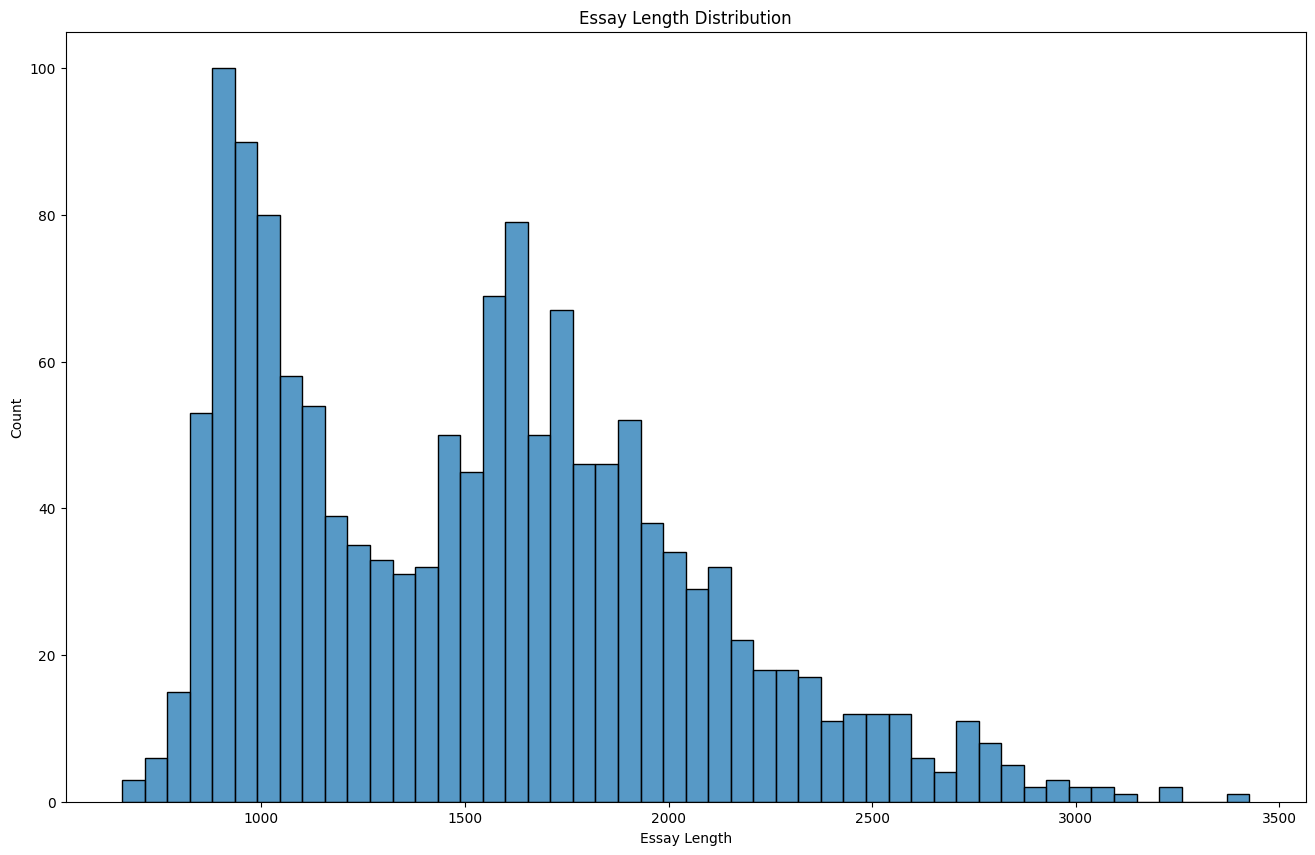

In [9]:
df['essay_len'] = df['Essay'].apply(len)

plt.figure(figsize=(16,10))
sns.histplot(df['essay_len'],bins=50)
plt.title('Essay Length Distribution')
plt.xlabel('Essay Length')
plt.ylabel('Count')
plt.show()

In [12]:
import re

def clean_text(text):
  text = text.lower()
  text = re.sub(r'[a-zA-Z]','',text)
  return text

df['clean_essay'] = df['Essay'].apply(clean_text)

In [14]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained('gpt2')

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [17]:
tokenizer.pad_token = tokenizer.eos_token

In [18]:
tokens = tokenizer(
    df['clean_essay'][0],
    truncation=True,
    padding='max_length',
    max_length=128
)

In [19]:
from transformers import pipeline

generator = pipeline('text-generation',model='distilgpt2')

config.json:   0%|          | 0.00/762 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/353M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: distilgpt2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
transformer.h.{0, 1, 2, 3, 4, 5}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [20]:
prompt = "Write an essay about Artificial Intelligence in Education"

essay = generator(
    prompt,
    max_length=300,
    temperature=0.7
)

print(essay[0]['generated_text'])

Passing `generation_config` together with generation-related arguments=({'temperature', 'max_length'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=300) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Write an essay about Artificial Intelligence in Education.

In 2013, I published a blog article outlining the research paper by George P. M. Bush. I am sure many of you have heard that the term "intelligence" has been used to describe a wide range of people. I hope you will too!
As I wrote two weeks ago, I wanted to share my work with you and my work with you to explore the research paper. I hope you will share my work with you and my work with you to explore the research paper. I hope you will share my work with you and my work with you to explore the research paper. I hope you will share my work with you and my work with you to explore the research paper. I hope you will share my work with you and my work with you to explore the research paper. I hope you will share my work with you and my work with you to explore the research paper. I hope you will share my work with you and your work with you to explore the research paper. I hope you will share my work with you and my work with you